In [49]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt 

In [50]:
#open the data

data_10gev = pd.read_csv('./data/df_result_10GeV.csv')
df_10gev = pd.DataFrame(data_10gev)

In [51]:
#data_1gev = pd.read_csv('./data/df_result_1GeV.csv')
#df_1gev = pd.DataFrame(data_1gev)

In [52]:
data_10gev.head(10)

,hit_index,sensor_hit_index,track_index,x_intersect,y_intersect,z_intersect,x_hit,y_hit,z_hit,pT,...,distance,matched_sensor_id,sensor_x_mm,sensor_y_mm,sensor_z_mm,candidate_sensor_ids,hit_row,hit_col,expected_row,expected_col
0,0,0,315,-124.005344,38.395195,132.488617,-124.052570,38.316340,132.488620,6.928290,...,0.091912,436.0,-126.253165,28.816461,135.45,[436],981.0,690.0,985.149370,691.912807
1,1,0,875,-109.611564,64.789935,129.695312,-110.099590,64.008385,129.695310,6.942005,...,0.921405,404.0,-114.423046,55.103235,135.45,[404],958.0,774.0,989.467997,794.459289
2,2,0,780,-17.598384,126.188840,127.816147,-18.251888,126.067856,127.816150,7.048605,...,0.664609,276.0,-28.260159,123.815845,135.45,[276],692.0,1002.0,696.919793,1028.470998
3,3,0,130,94.122275,-89.707851,128.062073,93.959656,-89.829666,128.062070,7.179455,...,0.203185,820.0,101.247177,-80.741929,135.45,"[788, 820]",238.0,310.0,243.363147,317.003935
4,4,0,442,127.701829,21.746546,126.874275,127.659270,22.514332,126.874275,7.219651,...,0.768964,52.0,126.253165,28.816461,135.45,[52],349.0,658.0,319.203414,659.946568
5,5,0,173,-54.442160,117.440323,130.636185,-54.987816,117.218460,130.636180,7.006629,...,0.589036,308.0,-56.187944,116.675468,135.45,[308],623.0,650.0,632.594199,671.831377
6,6,0,668,-49.087644,120.135592,130.853912,-48.465470,120.359450,130.853910,7.012895,...,0.661222,308.0,-56.187944,116.675468,135.45,[308],749.0,910.0,740.404936,886.011990
7,7,0,852,-50.741057,-119.250933,130.701920,-50.313606,-119.469440,130.701920,7.011305,...,0.480061,628.0,-56.187944,-116.675468,135.45,[628],490.0,836.0,498.981422,819.875475
8,8,0,178,-100.733242,81.272592,131.609207,-100.599500,81.503560,131.609200,6.954048,...,0.266897,372.0,-101.247177,80.741929,135.45,[372],632.0,627.0,623.226487,622.557397
9,9,0,697,127.083865,25.023557,126.871201,127.135720,24.808160,126.871200,7.218926,...,0.221550,52.0,126.253165,28.816461,135.45,[52],441.0,637.0,450.283860,635.228009


In [53]:
df = df_10gev[
    (df_10gev["expected_row"] >= 0) &
    (df_10gev["expected_col"] >= 0) &
    (df_10gev["expected_row"] <= 1200) &  # optional upper bound
    (df_10gev["expected_col"] <= 1200)
].copy()

In [54]:
# df = df_1gev[
#     (df_1gev["expected_row"] >= 0) &
#     (df_1gev["expected_col"] >= 0) &
#     (df_1gev["expected_row"] <= 1200) &  # optional upper bound
#     (df_1gev["expected_col"] <= 1200)
# ].copy()


In [55]:
#input and target

input_feat = ["x_intersect","y_intersect","z_intersect","pT","sensor_x_mm","sensor_y_mm","sensor_z_mm"]
output_feat = ["expected_row","expected_col"]

#filter and scale inputs

X = df[input_feat].values
y = df[output_feat].values


scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)


#convert to torch 
X = torch.tensor(X_scaled, dtype=torch.float32)
y = torch.tensor(y_scaled,dtype=torch.float32)


#train_test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [56]:
X_train[0]

tensor([-1.3645, -0.0404,  0.3002, -1.3735, -1.3720, -0.0381,  0.0420])

In [57]:
class HitPredictorNN(nn.Module):
    def __init__(self,input_size,hidden_size,output_size):
        super(HitPredictorNN,self).__init__()
        
        # a fully connected layer from input to hidden
        self.fc1 = nn.Linear(input_size,hidden_size)
        
        # non-linear activation
        self.relu = nn.ReLU()
        
        # a fully connected layer from hidden to output
        self.fc2 = nn.Linear(hidden_size,output_size)
        
    def forward(self,x):
        # feed input through the first layer
        out = self.fc1(x)
        
        # apply the ReLu
        out = self.relu(out)
        
        # feed through output
        out = self.fc2(out)
        
        return out

In [58]:
input_size = 7
hidden_size = 64
output_size = 2

model = HitPredictorNN(input_size, hidden_size, output_size)

In [59]:
# define loss
loss_fn = nn.MSELoss()

#define optimizer
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [60]:
# train the model

num_epochs = 1000

loss_trk = []

for epoch in range(num_epochs):
    #set model to train
    model.train()
    
    # clear gradient from previous steps
    optimizer.zero_grad()
    
    # predict in train datasets
    outputs = model(X_train)
    
    #compute loss
    loss = loss_fn(outputs,y_train)
    
    #backpropagate (compute gradient)
    loss.backward()
    
    #update weights
    optimizer.step()
    
    if (epoch+1)% 10 ==0:
        loss_trk.append(loss.item())
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [10/1000], Loss: 1.0052
Epoch [20/1000], Loss: 0.9905
Epoch [30/1000], Loss: 0.9812
Epoch [40/1000], Loss: 0.9719
Epoch [50/1000], Loss: 0.9645
Epoch [60/1000], Loss: 0.9567
Epoch [70/1000], Loss: 0.9492
Epoch [80/1000], Loss: 0.9415
Epoch [90/1000], Loss: 0.9335
Epoch [100/1000], Loss: 0.9251
Epoch [110/1000], Loss: 0.9158
Epoch [120/1000], Loss: 0.9058
Epoch [130/1000], Loss: 0.8951
Epoch [140/1000], Loss: 0.8837
Epoch [150/1000], Loss: 0.8715
Epoch [160/1000], Loss: 0.8587
Epoch [170/1000], Loss: 0.8446
Epoch [180/1000], Loss: 0.8292
Epoch [190/1000], Loss: 0.8123
Epoch [200/1000], Loss: 0.7946
Epoch [210/1000], Loss: 0.7753
Epoch [220/1000], Loss: 0.7550
Epoch [230/1000], Loss: 0.7340
Epoch [240/1000], Loss: 0.7120
Epoch [250/1000], Loss: 0.6880
Epoch [260/1000], Loss: 0.6625
Epoch [270/1000], Loss: 0.6360
Epoch [280/1000], Loss: 0.6082
Epoch [290/1000], Loss: 0.5820
Epoch [300/1000], Loss: 0.5555
Epoch [310/1000], Loss: 0.5286
Epoch [320/1000], Loss: 0.5014
Epoch [330/1000],

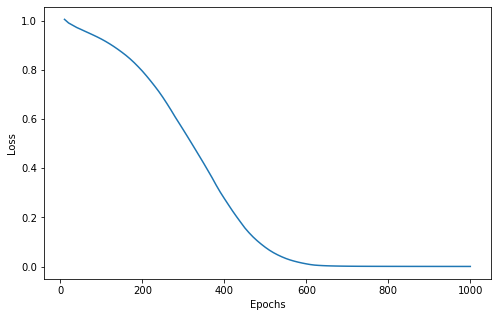

In [61]:
plt.figure(figsize = (8,5))
plt.plot(range(10,num_epochs+1,10),loss_trk)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [62]:
#set the model to evaluation mode 
model.eval()

#diable grad computing during eval 
with torch.no_grad():
    y_pred = model(X_test)


# Convert predictions to numpy
y_pred_np = y_pred.numpy()
y_test_np = y_test.numpy()

# Inverse transform
y_pred_original = scaler_y.inverse_transform(y_pred_np)
y_test_original = scaler_y.inverse_transform(y_test_np)

In [70]:
y_pred_original[0]

array([619.7223, 529.8409], dtype=float32)

In [71]:
y_test_original[0]

array([619.69165, 529.28424], dtype=float32)

In [63]:
#compute error metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² score: {r2:.4f}")

MAE: 3.67
MSE: 32.91
R² score: 0.9994


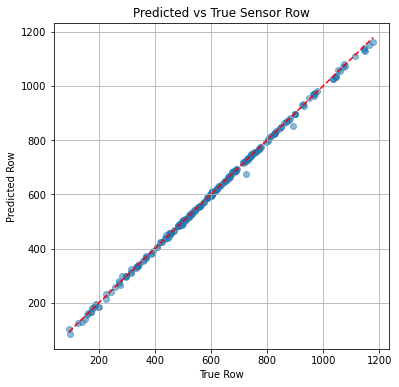

In [64]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_original[:, 0], y_pred_original[:, 0], alpha=0.5)
plt.xlabel("True Row")
plt.ylabel("Predicted Row")
plt.title("Predicted vs True Sensor Row")
plt.plot([y_test_original[:, 0].min(), y_test_original[:, 0].max()],
         [y_test_original[:, 0].min(), y_test_original[:, 0].max()],
         'r--')
plt.grid(True)
plt.show()


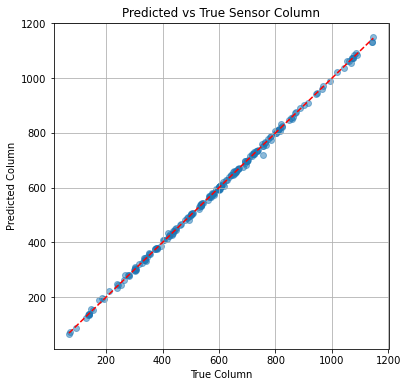

In [65]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_original[:, 1], y_pred_original[:, 1], alpha=0.5)
plt.xlabel("True Column")
plt.ylabel("Predicted Column")
plt.title("Predicted vs True Sensor Column")
plt.plot([y_test_original[:, 1].min(), y_test_original[:, 1].max()],
         [y_test_original[:, 1].min(), y_test_original[:, 1].max()],
         'r--')
plt.grid(True)
plt.show()


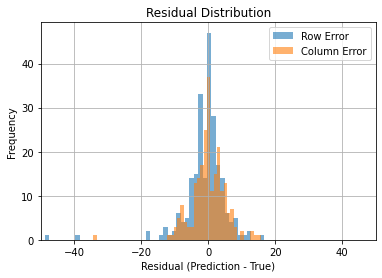

In [67]:
residuals_row = y_pred_original[:, 0] - y_test_original[:, 0]
residuals_col = y_pred_original[:, 1] - y_test_original[:, 1]

plt.hist(residuals_row, bins=50, alpha=0.6, label='Row Error')
plt.hist(residuals_col, bins=50, alpha=0.6, label='Column Error')
plt.xlabel("Residual (Prediction - True)")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.legend()
plt.grid(True)
plt.xlim(-50,50)
plt.show()

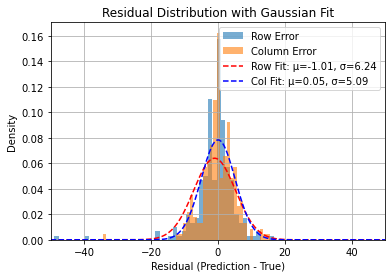

In [76]:
from scipy.stats import norm

# Residuals
residuals_row = y_pred_original[:, 0] - y_test_original[:, 0]
residuals_col = y_pred_original[:, 1] - y_test_original[:, 1]

# Fit Gaussian: returns (mu, sigma)
mu_row, sigma_row = norm.fit(residuals_row)
mu_col, sigma_col = norm.fit(residuals_col)

# Plot histogram
plt.hist(residuals_row, bins=50, density=True, alpha=0.6, label='Row Error')
plt.hist(residuals_col, bins=50, density=True, alpha=0.6, label='Column Error')

# Plot fitted Gaussians
x = np.linspace(-50, 50, 1000)
plt.plot(x, norm.pdf(x, mu_row, sigma_row), 'r--', label=f'Row Fit: μ={mu_row:.2f}, σ={sigma_row:.2f}')
plt.plot(x, norm.pdf(x, mu_col, sigma_col), 'b--', label=f'Col Fit: μ={mu_col:.2f}, σ={sigma_col:.2f}')

plt.xlabel("Residual (Prediction - True)")
plt.ylabel("Density")
plt.title("Residual Distribution with Gaussian Fit")
plt.legend()
plt.grid(True)
plt.xlim(-50, 50)
#plt.savefig('./plots/prediction_error.png')
plt.show()
